<a href="https://colab.research.google.com/github/elifguv/lulc-monitoring/blob/main/Senior_project_RGBModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. Connect to google drive
from google.colab import drive
drive.mount('/content/drive')

# 2. Unzip the dataset into Colab's temporary storage
!unzip -q "/content/drive/MyDrive/Senior_project/EuroSAT_RGB.zip" -d "/content/dataset"

print("Dataset successfully loaded")

Mounted at /content/drive
Dataset successfully loaded


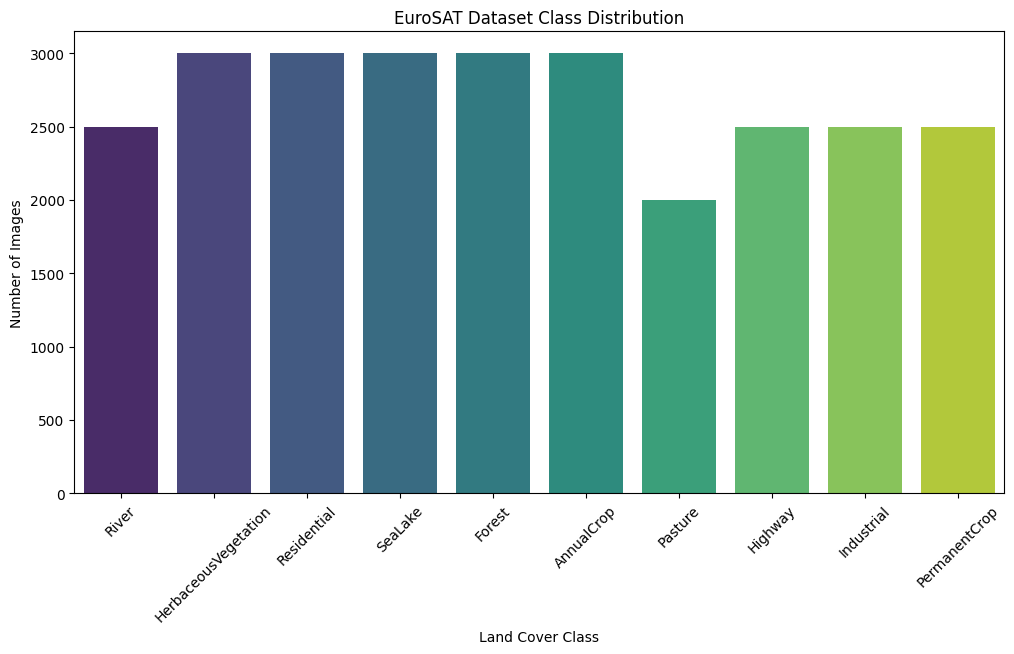

Total images found: 27000
Class names: ['River', 'HerbaceousVegetation', 'Residential', 'SeaLake', 'Forest', 'AnnualCrop', 'Pasture', 'Highway', 'Industrial', 'PermanentCrop']


In [ ]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Locate the exact extracted folder
base_dir = '/content/dataset'
dataset_dir = base_dir

# Handle nested folders if the zip created them
if '2750' in os.listdir(base_dir):
    dataset_dir = os.path.join(base_dir, '2750')
elif 'EuroSAT_RGB' in os.listdir(base_dir):
    dataset_dir = os.path.join(base_dir, 'EuroSAT_RGB')

# 2. Count the images in each class
class_names = [d for d in os.listdir(dataset_dir) if os.path.isdir(os.path.join(dataset_dir, d))]
class_counts = {}

for c in class_names:
    class_path = os.path.join(dataset_dir, c)
    class_counts[c] = len(os.listdir(class_path))

# 3. Plot the EDA Bar Chart
plt.figure(figsize=(12, 6))
sns.barplot(
    x=list(class_counts.keys()),
    y=list(class_counts.values()),
    hue=list(class_counts.keys()),
    palette='viridis',
    legend=False
)
plt.title('EuroSAT Dataset Class Distribution')
plt.xlabel('Land Cover Class')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)
plt.show()

print(f"Total images found: {sum(class_counts.values())}")
print(f"Class names: {class_names}")

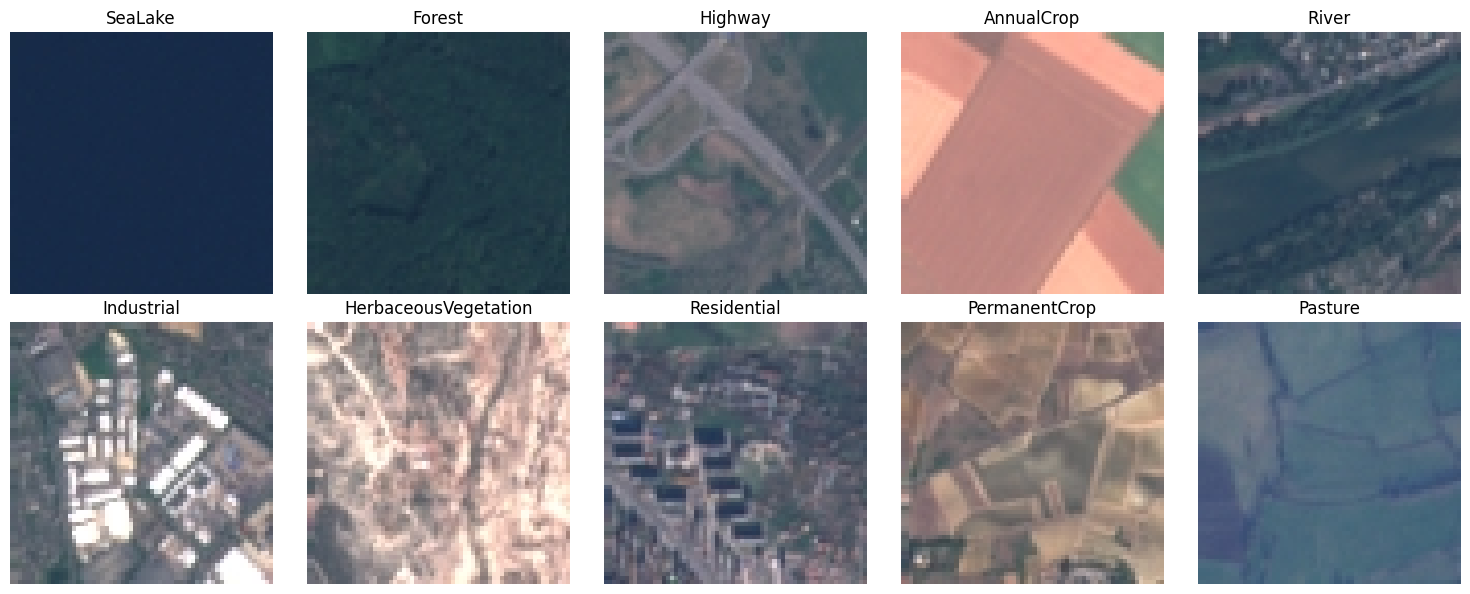

In [ ]:
import cv2
import numpy as np

plt.figure(figsize=(15, 6))

# Loop through each class and plot the very first image
for i, class_name in enumerate(class_names):
    class_dir = os.path.join(dataset_dir, class_name)
    first_image_file = os.listdir(class_dir)[0]
    img_path = os.path.join(class_dir, first_image_file)

    # Read image with OpenCV
    img = cv2.imread(img_path)
    # Convert BGR to RGB for the colors to look normal to human eyes
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Create a subplot for each of the 10 classes
    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import tensorflow as tf

# Process images in batches to save RAM
BATCH_SIZE = 32
# Use 64x64 images for ResNet.
IMG_SIZE = (64, 64)

print("Preparing Training Data...")
train_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="training",
    seed=123, # Get the same split every time
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

print("\nPreparing Validation Data...")
val_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Optimize the datasets for faster loading
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)

print("\nDatasets successfully split and optimized for performance")

Preparing Training Data...
Found 27000 files belonging to 10 classes.
Using 21600 files for training.

Preparing Validation Data...
Found 27000 files belonging to 10 classes.
Using 5400 files for validation.

Datasets successfully split and optimized for performance!


In [ ]:
from tensorflow.keras import layers, models, Sequential
from tensorflow.keras.applications import ResNet50

# Data Augmentation Layers
data_augmentation = Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1),
])

# ResNet50
# Exclude the top classification layer
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False # Freeze the layers

# 10 EuroSAT classes
model = models.Sequential([
    layers.Input(shape=(64, 64, 3)),
    layers.Resizing(224, 224),
    data_augmentation,
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing_3 (Resizing)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_6 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,114,826 (91.99 MB)

 Trainable params: 527,114 (2.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Stop training if the validation loss doesn't improve for 5 rounds
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# Slow down the learning rate if the model gets stuck
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6
)

callbacks = [early_stopping, reduce_lr]

In [ ]:
EPOCHS = 15

print("Training starting...")
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=callbacks
)

print("\nTraining Complete!")

# Save the trained model
model_path = '/content/drive/MyDrive/Senior_project/bursa_resnet50_v1.keras'
model.save(model_path)

Training starting...
Epoch 1/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 401s 574ms/step - accuracy: 0.8317 - loss: 0.5326 - val_accuracy: 0.8756 - val_loss: 0.3818 - learning_rate: 0.0010
Epoch 2/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 369s 547ms/step - accuracy: 0.8803 - loss: 0.3565 - val_accuracy: 0.9033 - val_loss: 0.3050 - learning_rate: 0.0010
Epoch 3/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 372s 551ms/step - accuracy: 0.8904 - loss: 0.3277 - val_accuracy: 0.9126 - val_loss: 0.2724 - learning_rate: 0.0010
Epoch 4/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 370s 548ms/step - accuracy: 0.8981 - loss: 0.3051 - val_accuracy: 0.9059 - val_loss: 0.2940 - learning_rate: 0.0010
Epoch 5/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 384s 569ms/step - accuracy: 0.8990 - loss: 0.3003 - val_accuracy: 0.9072 - val_loss: 0.2899 - learning_rate: 0.0010
Epoch 6/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 369s 547ms/step - accuracy: 0.9015 - loss: 0.2885 - val_accuracy: 0.9198 - val_loss: 0.2466 - learning_rate: 0.0010
Epoch 7/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 369

In [ ]:
from google.colab import drive
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

drive.mount('/content/drive')

print("Loading the first model from Drive...")
model_path = '/content/drive/MyDrive/Senior_project/bursa_resnet50_v1.keras'
model = tf.keras.models.load_model(model_path)

print("Unfreezing the base model...")
# Unfreeze the ResNet50 layer
for layer in model.layers:
    if layer.name.startswith('resnet50'):
        layer.trainable = True

print("Recompiling with a micro-learning rate...")
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Re-establish the safety nets
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)
]

print("Starting Fine-Tuning Phase on GPU...")
history_fine = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=40,
    callbacks=callbacks
)

print("\nFine-Tuning Complete")
model.save('/content/drive/MyDrive/Senior_project/bursa_resnet50_finetuned.keras')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading the first model from Drive...
Unfreezing the base model...
Recompiling with a micro-learning rate...
Starting Fine-Tuning Phase on GPU...
Epoch 1/40
675/675 ━━━━━━━━━━━━━━━━━━━━ 128s 122ms/step - accuracy: 0.8801 - loss: 0.4006 - val_accuracy: 0.9120 - val_loss: 0.2711 - learning_rate: 1.0000e-04
Epoch 2/40
675/675 ━━━━━━━━━━━━━━━━━━━━ 77s 115ms/step - accuracy: 0.9337 - loss: 0.2065 - val_accuracy: 0.9387 - val_loss: 0.1930 - learning_rate: 1.0000e-04
Epoch 3/40
675/675 ━━━━━━━━━━━━━━━━━━━━ 78s 116ms/step - accuracy: 0.9453 - loss: 0.1739 - val_accuracy: 0.9476 - val_loss: 0.1641 - learning_rate: 1.0000e-04
Epoch 4/40
675/675 ━━━━━━━━━━━━━━━━━━━━ 78s 115ms/step - accuracy: 0.9525 - loss: 0.1493 - val_accuracy: 0.9233 - val_loss: 0.3473 - learning_rate: 1.0000e-04
Epoch 5/40
675/675 ━━━━━━━━━━━━━━━━━━━━ 78s 116ms/step - accuracy: 0.9550 - loss: 0.1368

In [ ]:
from tensorflow.keras import layers, models, Sequential
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Build the architecture
data_augmentation = Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.1),
])

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

# 224x224 Resizing Architecture
model = models.Sequential([
    layers.Input(shape=(64, 64, 3)),
    layers.Resizing(224, 224),
    data_augmentation,
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)
]

# Adam optimizer
print("Adam optimizer...")
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
# Stabilize the model
model.fit(train_dataset, validation_data=val_dataset, epochs=5, callbacks=callbacks)

# Fine-tuning with SGD
print("\nUnfreezing base model and Fine-Tuning with SGD...")
base_model.trainable = True

model.compile(
    optimizer=SGD(learning_rate=1e-4, momentum=0.9),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(train_dataset, validation_data=val_dataset, epochs=20, callbacks=callbacks)

final_path = '/content/drive/MyDrive/Senior_project/bursa_resnet50_sgd_final.keras'
model.save(final_path)
print(f"Saved to drive: {final_path}")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Adam optimizer...
Epoch 1/5
675/675 ━━━━━━━━━━━━━━━━━━━━ 133s 174ms/step - accuracy: 0.8971 - loss: 0.3052 - val_accuracy: 0.9309 - val_loss: 0.2175 - learning_rate: 0.0010
Epoch 2/5
675/675 ━━━━━━━━━━━━━━━━━━━━ 120s 177ms/step - accuracy: 0.9366 - loss: 0.1864 - val_accuracy: 0.9389 - val_loss: 0.1978 - learning_rate: 0.0010
Epoch 3/5
675/675 ━━━━━━━━━━━━━━━━━━━━ 120s 178ms/step - accuracy: 0.9407 - loss: 0.1733 - val_accuracy: 0.9511 - val_loss: 0.1532 - learning_rate: 0.0010
Epoch 4/5
675/675 ━━━━━━━━━━━━━━━━━━━━ 121s 179ms/step - accuracy: 0.9448 - loss: 0.1617 - val_accuracy: 0.9481 - val_loss: 0.1653 - learning_rate: 0.0010
Epoch 5/5
675/675 ━━━━━━━━━━━━━━━━━━━━ 120s 179ms/step - accuracy: 0.9499 - loss: 0.1488 - val_accuracy: 0.9506 - val_loss: 0.1610 - learning_rate: 0.0010

Unfreezing base model and Fine-Tuning with SGD...
Epoch 1/20
675/675 ━━━━━━━━━━━━━━━━━━━━ 426s 593ms/step - accuracy: 0.8821 - loss: 0.4140 - val_accuracy:

In [ ]:
import tensorflow as tf

print("Loading the Final SGD Model from Drive...")
final_path = '/content/drive/MyDrive/Senior_project/bursa_resnet50_sgd_final.keras'
model = tf.keras.models.load_model(final_path)

print("Model loaded successfully. Ready for evaluation.")

Loading the Final SGD Model from Drive...
Model loaded successfully. Ready for evaluation.


Evaluating the model on the Validation Set...

Classification Report:

                      precision    recall  f1-score   support

          AnnualCrop       0.98      0.98      0.98       559
              Forest       0.99      1.00      0.99       614
HerbaceousVegetation       0.96      0.98      0.97       589
             Highway       0.98      0.98      0.98       499
          Industrial       0.99      0.99      0.99       488
             Pasture       0.99      0.96      0.97       393
       PermanentCrop       0.97      0.96      0.97       529
         Residential       0.99      1.00      1.00       637
               River       0.98      0.98      0.98       491
             SeaLake       1.00      1.00      1.00       601

            accuracy                           0.98      5400
           macro avg       0.98      0.98      0.98      5400
        weighted avg       0.98      0.98      0.98      5400



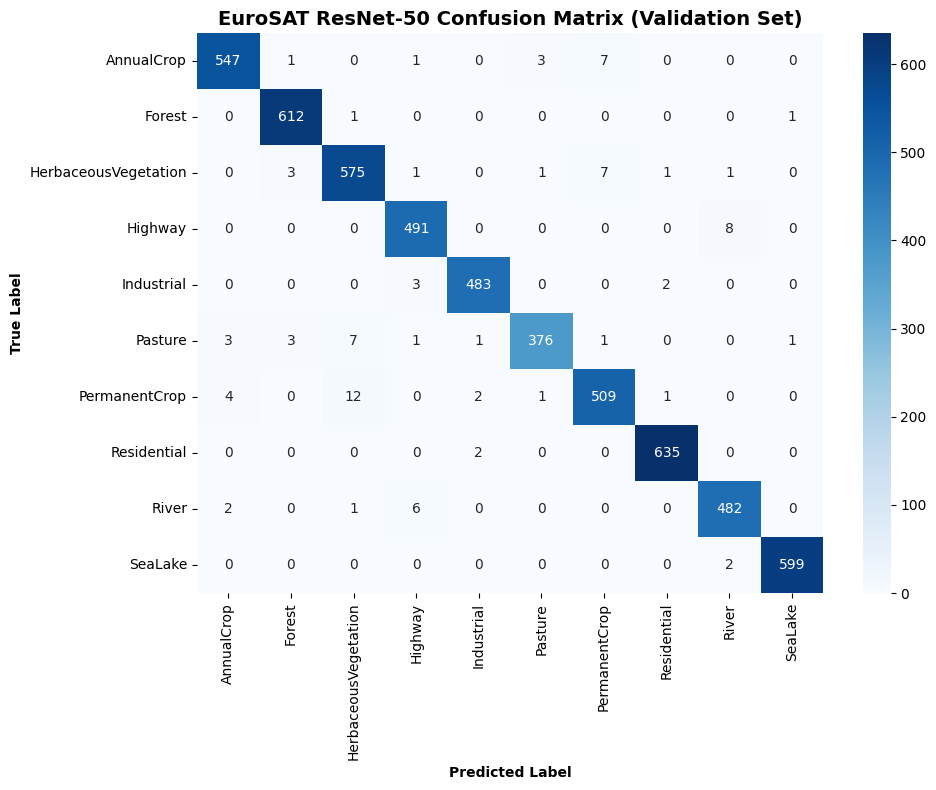

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print("Evaluating the model on the Validation Set...")

# Extract the true labels and predicted labels from the validation dataset
y_true = []
y_pred_probs = []

# Loop through the validation batches
for images, labels in val_dataset:
    y_true.extend(labels.numpy())
    preds = model.predict(images, verbose=0)
    y_pred_probs.extend(preds)

y_true = np.array(y_true)
y_pred = np.argmax(y_pred_probs, axis=1)

# Dynamically read and sort the class names straight from the dataset folder
class_names = sorted([d for d in os.listdir(dataset_dir) if os.path.isdir(os.path.join(dataset_dir, d))])

# Print the classification report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

# Plot the confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)

plt.xlabel('Predicted Label', fontweight='bold')
plt.ylabel('True Label', fontweight='bold')
plt.title('EuroSAT ResNet-50 Confusion Matrix (Validation Set)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()